# ActD RNA stability: time courses and per-cell half-times

This notebook plots the condition-level ActD time courses and the distribution of exponential-fit half-times for individual cells.

In [ ]:
from pathlib import Path
import sys
revisions_dir = Path.cwd().resolve()
if not (revisions_dir / 'inhibitors.py').exists():
    revisions_dir = revisions_dir / 'notebooks' / 'revisions_paper'
if not (revisions_dir / 'inhibitors.py').exists():
    raise FileNotFoundError('Run this notebook from the repository root or notebooks/revisions_paper.')
sys.path.insert(0, str(revisions_dir))
import inhibitors as INH

## Data configuration

In [2]:
rna_stability_dir = revisions_dir / 'rna_stability'

experiment_dir_dmso = rna_stability_dir / 'KM5B_DMSO'
experiment_dir_kdm5b = rna_stability_dir / 'KDM5B_5ugml_ActD'
experiment_dir_utag_kdm5b = rna_stability_dir / 'UTag_KDM5B_MS2_noIntrabody'
experiment_dir_utag_ib_kdm5b = rna_stability_dir / 'UTag_KDM5B_MS2_wIntrabody'

data_dirs = [
    experiment_dir_dmso / 'results',
    experiment_dir_kdm5b / 'results',
    experiment_dir_utag_kdm5b / 'results',
    experiment_dir_utag_ib_kdm5b / 'results',
]

experiment_lif_files = {
    'control': experiment_dir_dmso / '20260710_pNZ424_pNN025_DMSOcontrol.lif',
    'kdm5b_1': experiment_dir_kdm5b / '20260709 pNZ424_pNN025_20minDelay_8h.lif',
    'kdm5b_2': experiment_dir_kdm5b / '20260715_pNZ424_pNN025_ActD_5ugml.lif',
    'kdm5b_3': experiment_dir_kdm5b / '20260715_pNZ424_pNN025_ActD_5ugml_Dish2.lif',
    'utag_kdm5b_1': experiment_dir_utag_kdm5b / '20260720_pNZ208_pNN025_5ugmLActD.lif',
    'utag_kdm5b_2': experiment_dir_utag_kdm5b / '20260720_pNZ208_pNN025_5ugmLActD_dish2.lif',
    'utag_kdm5b_ib_1': experiment_dir_utag_ib_kdm5b / '20260724_pNZ208_pNN025_pNZ424.lif',
    'utag_kdm5b_ib_2': experiment_dir_utag_ib_kdm5b / '20260724_pNZ208_pNN025_pNZ424_dish2.lif',
}

condition_labels = {
    'control': 'Control',
    'kdm5b_1': 'KDM5B',
    'kdm5b_2': 'KDM5B',
    'kdm5b_3': 'KDM5B',
    'utag_kdm5b_1': 'KDM5B + UTag',
    'utag_kdm5b_2': 'KDM5B + UTag',
    'utag_kdm5b_ib_1': 'KDM5B + UTag + IB',
    'utag_kdm5b_ib_2': 'KDM5B + UTag + IB',
}

In [3]:
particle_counts_df = INH.load_particle_counts_by_experiment(
    data_dir=data_dirs,
    experiment_lif_files=experiment_lif_files,
    condition_labels=condition_labels,
    baseline_frames=1,
    after_only=True,
    verbose=True,
)

max_frame = 12
particle_counts_df = particle_counts_df[particle_counts_df['frame'] <= max_frame].copy()

                 cells  frames  interval_sec  max_time_min
experiment                                                
control              8      20        1200.0         380.0
kdm5b_1              1      25        1200.0         480.0
kdm5b_2              5      16        1200.0         300.0
kdm5b_3              8      20        1200.0         380.0
utag_kdm5b_1         9      19        1200.0         360.0
utag_kdm5b_2         6      21        1200.0         400.0
utag_kdm5b_ib_1      9      20        1200.0         380.0
utag_kdm5b_ib_2      9      20        1200.0         380.0


## Processing summary

In [10]:
summary_df = particle_counts_df.groupby(['condition', 'experiment'], sort=False).agg(
    cells=('cell_key', 'nunique'),
    frames=('active_frame_count', 'max'),
    interval_min=('frame_interval_sec', lambda values: values.iloc[0] / 60),
    max_time_min=('time_min', 'max'),
)
print(summary_df)

                                   cells  frames  interval_min  max_time_min
condition         experiment                                                
Control           control              8      20          20.0         240.0
KDM5B             kdm5b_1              1      25          20.0         240.0
                  kdm5b_2              5      16          20.0         240.0
                  kdm5b_3              8      20          20.0         240.0
KDM5B + UTag      utag_kdm5b_1         9      19          20.0         240.0
                  utag_kdm5b_2         6      21          20.0         240.0
KDM5B + UTag + IB utag_kdm5b_ib_1      9      20          20.0         240.0
                  utag_kdm5b_ib_2      9      20          20.0         240.0


## Plot configuration

In [5]:
condition_repetitions = {
    'KDM5B': ('kdm5b_1', 'kdm5b_2', 'kdm5b_3'),
    'KDM5B + UTag': ('utag_kdm5b_1', 'utag_kdm5b_2'),
    'KDM5B + UTag + IB': ('utag_kdm5b_ib_1', 'utag_kdm5b_ib_2'),
}
condition_colors = {
    'Control': ['#4D4D4D'],
    'KDM5B': ['#A84300', '#D55E00', '#F3A261'],
    'KDM5B + UTag': ['#1F4E79', '#74A9CF'],
    'KDM5B + UTag + IB': ['#5B3C88', '#B39DDB'],
}
condition_mean_colors = {
    'Control': '#4D4D4D',
    'KDM5B': '#D55E00',
    'KDM5B + UTag': '#1F77B4',
    'KDM5B + UTag + IB': '#8064A2',
}
condition_display_labels = {
    'KDM5B': 'KDM5B',
    'KDM5B + UTag': 'KDM5B\n+ UTag',
    'KDM5B + UTag + IB': 'KDM5B\n+ UTag + IB',
}

fit_start_idx = 0
half_life_target = 0.5
results_folder = revisions_dir / 'results_ActD_KDM5B_UTag_cell_half_times'

## Condition-level time courses

Condition-level exponential fits are shown without half-time guide lines.


Half-life summary
        Condition Half time (min) Half time (h)
            KDM5B          147.43          2.46
     KDM5B + UTag          164.05          2.73
KDM5B + UTag + IB          191.39          3.19


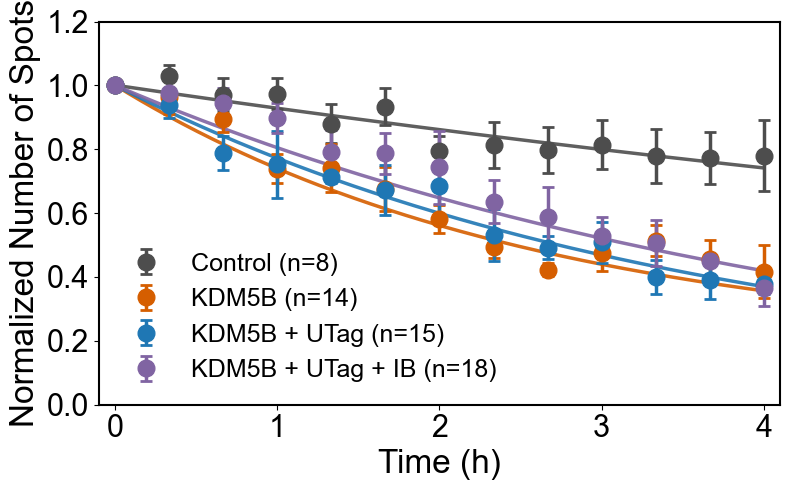

In [6]:
cell_half_times_df = INH.calculate_actd_cell_half_times(
    particle_counts_df=particle_counts_df,
    condition_repetitions=condition_repetitions,
    value_column='normalized_particle_count',
    fit_start_idx=fit_start_idx,
    half_life_target=half_life_target,
)
condition_fit_results = INH.plot_actd_conditions(
    particle_counts_df=particle_counts_df,
    condition_repetitions=condition_repetitions,
    comparison='average',
    control_experiment='control',
    control_label='Control',
    condition_colors=condition_colors,
    condition_mean_colors=condition_mean_colors,
    control_color='#4D4D4D',
    error_style='bar',
    connect_points=False,
    fit_model='exponential',
    fit_start_idx=fit_start_idx,
    show_fit=True,
    show_runoff_time=False,
    verbose=False,
    show_half_life_lines=False,
    show_half_life_table=True,
    half_life_target=half_life_target,
    half_life_exclude_labels=('Control',),
    show_treatment_line=False,
    require_all_repetitions=True,
    use_sem=True,
    figsize=(8, 5),
    ylims=(0.0, 1.2),
    xlims=(-0.1, 4.1),
    time_unit='h',
    show_individual_trajectories=False,
    font_family='Arial',
    axis_label_size=24,
    tick_label_size=22,
    legend_font_size=18,
    marker_size=12,
    data_line_width=2.5,
    error_bar_line_width=2.5,
    error_bar_cap_thickness=2,
    fit_line_width=2.5,
    y_label='Normalized Number of Spots',
    plot_name='KDM5B_UTag_average_half_target_band',
    legend_position='inside_lower_left',
    show_n_cells=True,
    results_folder=results_folder,
)

## Per-cell half-times

Each treated cell is fit independently. Invalid target crossings remain in the exported table with a descriptive status; no R² cutoff is applied. Swarm points above the global 95th percentile are omitted from the figure only.

In [11]:
half_time_summary_df = cell_half_times_df.groupby('condition', sort=False).agg(
    total_cells=('cell_key', 'nunique'),
    valid_half_times=('half_time_h', lambda values: values.notna().sum()),
    median_half_time_h=('half_time_h', 'median'),
    q25_half_time_h=('half_time_h', lambda values: values.quantile(0.25)),
    q75_half_time_h=('half_time_h', lambda values: values.quantile(0.75)),
    extrapolated=('extrapolated', 'sum'),
)
print(half_time_summary_df)

results_folder.mkdir(parents=True, exist_ok=True)
cell_half_times_df.to_csv(results_folder / 'ActD_cell_half_times.csv', index=False)

                   total_cells  valid_half_times  median_half_time_h  \
condition                                                              
KDM5B                       14                11            2.041522   
KDM5B + UTag                15                15            2.373249   
KDM5B + UTag + IB           18                18            2.763365   

                   q25_half_time_h  q75_half_time_h  extrapolated  
condition                                                          
KDM5B                     1.731307         3.061784             2  
KDM5B + UTag              1.242162         3.267526             3  
KDM5B + UTag + IB         2.229066         4.657375             6  



--- Per-cell half-times for ActD_cell_half_times_box_swarm ---
  Display: hiding 3 swarm point(s) above the 95th percentile (6.010).
  KDM5B: 3.971 ± 1.803 (n=11)
  KDM5B + UTag: 2.410 ± 0.361 (n=15)
  KDM5B + UTag + IB: 3.328 ± 0.383 (n=18)
--- End per-cell half-times ---



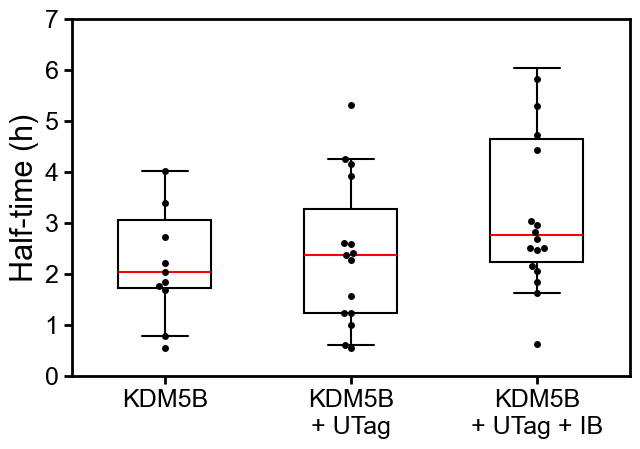

In [8]:
half_time_ax, half_time_p_values = INH.plot_cell_half_times_box_swarm(
    half_times_df=cell_half_times_df,
    condition_order=list(condition_repetitions),
    y_column='half_time_h',
    x_label='',
    y_label='Half-time (h)',
    title='',
    figsize=(6.5, 4.5),
    tick_size=18,
    swarm_color='black',
    y_lim=(0, 7),
    show_stats=True,
    calculate_stats=True,
    x_tick_rotation=0,
    condition_display_labels=condition_display_labels,
    swarm_max_percentile=95,
    save_dir=results_folder,
    plot_name='ActD_cell_half_times_box_swarm',
)

In [9]:
print("Pairwise p-values (Mann-Whitney U):", half_time_p_values)

Pairwise p-values (Mann-Whitney U): {'KDM5B vs KDM5B + UTag': 1.0, 'KDM5B vs KDM5B + UTag + IB': 0.15682829692617706, 'KDM5B + UTag vs KDM5B + UTag + IB': 0.07951258367192131}
